In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# check that we've got everything correctly

In [7]:
for trial in range(1,25):
    print(f"trial: {trial}")
    for algo in ['EI','KG','EICF','TS']:
        res = torch.load(f"/home/pb482/bott/results/GT_230.0_7.0_-3.0/{algo}/trial_{trial}.pt",map_location=torch.device('cpu'))
        print(f"algo: {algo}, first two vals: {res['obj_func_val'][0].numpy()}")
    print('==========================')

trial: 1
algo: EI, first two vals: [-0.0835831]
algo: KG, first two vals: [-0.0835831]
algo: EICF, first two vals: [-0.08358309]
algo: TS, first two vals: [-0.0835831]
trial: 2
algo: EI, first two vals: [-0.18070324]
algo: KG, first two vals: [-0.18070323]
algo: EICF, first two vals: [-0.18070322]
algo: TS, first two vals: [-0.18070323]
trial: 3
algo: EI, first two vals: [-0.0980113]
algo: KG, first two vals: [-0.0980113]
algo: EICF, first two vals: [-0.09801145]
algo: TS, first two vals: [-0.0980113]
trial: 4
algo: EI, first two vals: [-0.07098008]
algo: KG, first two vals: [-0.07098008]
algo: EICF, first two vals: [-0.07098008]
algo: TS, first two vals: [-0.07098008]
trial: 5
algo: EI, first two vals: [-0.17597282]
algo: KG, first two vals: [-0.17597282]
algo: EICF, first two vals: [-0.17597287]
algo: TS, first two vals: [-0.17597297]
trial: 6
algo: EI, first two vals: [-0.18011475]
algo: KG, first two vals: [-0.18011475]
algo: EICF, first two vals: [-0.18011475]
algo: TS, first two 

In [20]:
best_obj = {}
mean_acqf_time = {}
std_acqf_time = {}
mean_best_obj = {}
std_best_obj = {}
upper_best_obj = {}
lower_best_obj ={}
n_trial =21
for algo in ['EI','EICF','KG','TS']:
    print(f"algo: {algo}")
    best_obj[algo]={}
    acqf_time_temp=[]
    for trial in range(1,n_trial):
        res = torch.load(f"/home/pb482/bott/results/GT_230.0_7.0_-3.0/{algo}/trial_{trial}.pt",map_location=torch.device('cpu'))
        best_obj_temp = [max(res['obj_func_val'][0],res['obj_func_val'][1])]
        for iter in range(2,len(res['obj_func_val'])):
            best_obj_temp.append(max(best_obj_temp[-1],res['obj_func_val'][iter]))
            acqf_time_temp.append(res['acqf_runtime'][iter-2])
        best_obj[algo][trial]= best_obj_temp
    mean_acqf_time[algo]=np.mean(acqf_time_temp)
    std_acqf_time[algo]=np.std(acqf_time_temp)
    mean_best_obj[algo] = []
    std_best_obj[algo] = []
    for iter in range(2,51):
        mean_temp = []
        for trial in range(1,n_trial):
            # print(f"algo: {algo}, iter:{iter}, trial {trial}")
            mean_temp.append(-1*best_obj[algo][trial][iter-2])
        mean_best_obj[algo].append(np.mean(mean_temp))
        std_best_obj[algo].append(np.std(mean_temp))
        # if iter == 2:
        #     # print(f"algo {algo}: mean {np.mean(mean_temp)}")
    upper_best_obj[algo]=[mean_best_obj[algo][iter]+1.96*std_best_obj[algo][iter] for iter in range(48)]
    lower_best_obj[algo]=[mean_best_obj[algo][iter]-1.96*std_best_obj[algo][iter] for iter in range(48)]

algo: EI
algo: EICF
algo: KG
algo: TS


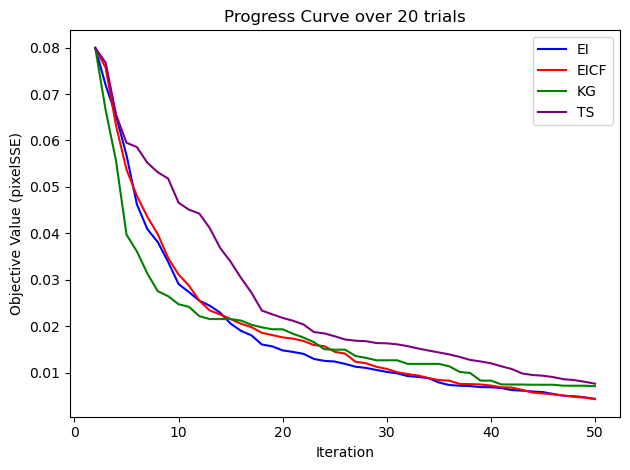

In [24]:
plt.plot(list(range(2,51)), mean_best_obj['EI'], label='EI', color='blue')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['EI'][1:]), np.log(upper_best_obj['EI'][1:]), color='blue', alpha=0.1)
plt.plot(list(range(2,51)), mean_best_obj['EICF'], label='EICF', color='red')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['EICF'][1:]), np.log(upper_best_obj['EICF'][1:]), color='red', alpha=0.1)
plt.plot(list(range(2,51)), mean_best_obj['KG'], label='KG', color='green')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['KG'][1:]), np.log(upper_best_obj['KG'][1:]), color='green', alpha=0.1)
plt.plot(list(range(2,51)), mean_best_obj['TS'], label='TS', color='purple')
# plt.fill_between(list(range(2,51)), lower_best_obj['TS'][1:], upper_best_obj['TS'][1:], color='purple', alpha=0.1)
plt.xlabel('Iteration')
plt.ylabel('Objective Value (pixelSSE)')
plt.title(f'Progress Curve over {n_trial-1} trials')
plt.legend()
plt.tight_layout()
plt.show()